In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split

class LBERTDataLoader:
    def __init__(self, pos_file, neg_file, random_state=42, test_size=0.2):
        self.pos_file = pos_file
        self.neg_file = neg_file
        self.random_state = random_state
        self.test_size = test_size

    def _parse_line(self, line):
        """Parses a single line from the dataset files."""
        parts = line.strip().split("\t")
        fname_indices = [i for i, p in enumerate(parts) if p.endswith(".txt")]
        if len(fname_indices) != 2: return None
        try:
            sentpair_id = int(parts[0]) 
            sent1 = " ".join(parts[fname_indices[0] + 2 : fname_indices[1]]).strip('"')
            sent2 = " ".join(parts[fname_indices[1] + 2 : len(parts) - 2]).strip('"')
            label = parts[-1]
        except (ValueError, IndexError): return None
        return {"sentpair_id": sentpair_id, "sent1": sent1, "sent2": sent2, "label": label}

    def load_aligned_dataframe(self):
        """
        Loads, cleans, splits, and recombines data exactly as done during 
        embedding generation to ensure row-to-row alignment.
        """
        rows = []
        # 1. Load raw data
        for fp in [self.pos_file, self.neg_file]:
            if os.path.exists(fp):
                with open(fp, "r", encoding="utf-8") as f:
                    for line in f:
                        parsed = self._parse_line(line)
                        if parsed: rows.append(parsed)
            else:
                print(f"Warning: File {fp} not found.")

        df = pd.DataFrame(rows)

        # 2. Clean and Map Labels
        LABEL_MAP = {"SUPPORT": 0, "ATTACK": 1, "NO_REL": 2}
        df["label_id"] = df["label"].map(LABEL_MAP)
        df = df.dropna(subset=["sentpair_id", "sent1", "sent2", "label_id"])

        # 3. Deterministic Split (Crucial for Alignment)
        train_df, test_df = train_test_split(
            df, 
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=df["label_id"]
        )

        # 4. Concatenate in exact order of embedding generation
        df_aligned = pd.concat([
            train_df.reset_index(drop=True), 
            test_df.reset_index(drop=True)
        ]).reset_index(drop=True)

        return df_aligned

In [2]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
from tqdm import tqdm

class DBSCANOptimizer:
    def __init__(self, embeddings, metric='cosine', n_jobs=-1):
        """
        Args:
            embeddings (np.array): The LegalBERT embeddings (N, 768).
            metric (str): Distance metric. 'cosine' is usually best for BERT embeddings.
            n_jobs (int): Number of parallel jobs.
        """
        self.embeddings = embeddings
        self.metric = metric
        self.n_jobs = n_jobs
        self.best_model = None
        self.best_params = {}
        self.best_score = -1

    def grid_search(self, eps_range, min_samples_range):
        """
        Performs a grid search to find optimal DBSCAN parameters.
        
        Args:
            eps_range (list): List of epsilon values to try (e.g., [0.1, 0.3, 0.5]).
            min_samples_range (list): List of min_samples values (e.g., [5, 10, 20]).
        """
        results = []
        print(f"Starting Grid Search over {len(eps_range) * len(min_samples_range)} combinations...")

        for eps in tqdm(eps_range, desc="Epsilon Loop"):
            for min_samples in min_samples_range:
                
                # Fit DBSCAN
                db = DBSCAN(eps=eps, min_samples=min_samples, metric=self.metric, n_jobs=self.n_jobs)
                labels = db.fit_predict(self.embeddings)

                # Evaluate
                # We ignore noise (-1) for silhouette calculation unless the whole set is noise
                unique_labels = set(labels)
                n_clusters = len(unique_labels) - (1 if -1 in labels else 0)

                if n_clusters > 1:
                    # Calculate Silhouette Score (Computationally expensive, sample if needed)
                    # For speed on large data, sample_size=10000 can be added to silhouette_score
                    score = silhouette_score(self.embeddings, labels, metric=self.metric, sample_size=5000)
                    
                    # Track best
                    if score > self.best_score:
                        self.best_score = score
                        self.best_params = {'eps': eps, 'min_samples': min_samples}
                        self.best_model = db
                    
                    results.append({
                        'eps': eps, 
                        'min_samples': min_samples, 
                        'n_clusters': n_clusters, 
                        'noise_ratio': np.sum(labels == -1) / len(labels),
                        'silhouette': score
                    })
                else:
                    # Case where no clusters or only 1 cluster is found
                    results.append({
                        'eps': eps, 
                        'min_samples': min_samples, 
                        'n_clusters': n_clusters, 
                        'noise_ratio': 1.0,
                        'silhouette': -1
                    })

        return pd.DataFrame(results)

    def get_best_labels(self):
        if self.best_model:
            return self.best_model.labels_
        return None

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

class ClusterVisualizer:
    def __init__(self, embeddings, labels, ground_truth=None):
        """
        Args:
            embeddings: The high-dim embeddings (N, 768)
            labels: The cluster labels from DBSCAN (including -1 for noise)
            ground_truth: (Optional) The actual labels (SUPPORT, ATTACK, etc.) for comparison
        """
        self.embeddings = embeddings
        self.labels = labels
        self.ground_truth = ground_truth
        self.coords_2d = None

    def reduce_dimensions(self, method='tsne', n_components=2, random_state=42):
        """
        Reduces dimensionality to 2D for plotting.
        """
        print(f"Reducing dimensions using {method.upper()}... this may take a moment.")
        
        if method == 'tsne':
            # t-SNE is best for preserving local cluster structure
            tsne = TSNE(n_components=n_components, random_state=random_state, 
                        perplexity=30, n_iter=1000, init='pca', learning_rate='auto')
            self.coords_2d = tsne.fit_transform(self.embeddings)
        elif method == 'pca':
            # PCA is faster but linear
            pca = PCA(n_components=n_components)
            self.coords_2d = pca.fit_transform(self.embeddings)
            
        return self.coords_2d

    def plot_clusters(self, title="DBSCAN Clusters (t-SNE Projection)"):
        """
        Plots the clusters. Noise points (-1) are colored grey and made smaller.
        """
        if self.coords_2d is None:
            self.reduce_dimensions()

        # Create a DataFrame for plotting
        plot_df = pd.DataFrame({
            'x': self.coords_2d[:, 0],
            'y': self.coords_2d[:, 1],
            'Cluster': self.labels
        })

        # Separate Noise from Clusters for better visualization handling
        noise_df = plot_df[plot_df['Cluster'] == -1]
        cluster_df = plot_df[plot_df['Cluster'] != -1]

        plt.figure(figsize=(12, 8))
        
        # Plot Noise (Grey, smaller, transparent)
        if not noise_df.empty:
            plt.scatter(noise_df['x'], noise_df['y'], c='lightgrey', label='Noise (-1)', 
                        s=10, alpha=0.3)

        # Plot Clusters (distinct colors)
        if not cluster_df.empty:
            sns.scatterplot(
                data=cluster_df, x='x', y='y', hue='Cluster', 
                palette='viridis', s=50, alpha=0.8, legend='full'
            )

        plt.title(title)
        plt.xlabel(f"Dimension 1")
        plt.ylabel(f"Dimension 2")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    def plot_vs_ground_truth(self):
        """
        Side-by-side comparison of DBSCAN clusters vs Ground Truth labels.
        """
        if self.coords_2d is None:
            self.reduce_dimensions()
            
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        
        # Plot 1: DBSCAN Clusters
        plot_df = pd.DataFrame({'x': self.coords_2d[:, 0], 'y': self.coords_2d[:, 1], 'Cluster': self.labels})
        sns.scatterplot(ax=axes[0], data=plot_df, x='x', y='y', hue='Cluster', 
                        palette='tab10', s=20, alpha=0.7)
        axes[0].set_title("DBSCAN Predicted Clusters")
        
        # Plot 2: Ground Truth
        if self.ground_truth is not None:
            gt_df = pd.DataFrame({'x': self.coords_2d[:, 0], 'y': self.coords_2d[:, 1], 'Label': self.ground_truth})
            sns.scatterplot(ax=axes[1], data=gt_df, x='x', y='y', hue='Label', 
                            palette='Set1', s=20, alpha=0.7)
            axes[1].set_title("Ground Truth Labels")
        
        plt.tight_layout()
        plt.show()

In [4]:
# --- Configuration ---
POS_FILE = "/kaggle/input/lrec-tcs-attack-support/sentencePair.txt"
NEG_FILE = "/kaggle/input/lrec-tcs-attack-support/sentencePair_neg.txt"
EMB_FILE = "/kaggle/input/lrec-tcs-attack-vs-support-finetuned-embeddings/lbert_finetuned_embeddings.npy"
EMB_ID_FILE = "/kaggle/input/lrec-tcs-attack-vs-support-finetuned-embeddings/lbert_finetuned_ids.csv"

# --- 1. Load Data and Embeddings ---
loader = LBERTDataLoader(POS_FILE, NEG_FILE)
df_text = loader.load_aligned_dataframe()

# Load your embeddings (ensure this path is correct in your environment)
if os.path.exists(EMB_FILE):
    embeddings = np.load(EMB_FILE)
    print(f"Data Loaded. Text: {df_text.shape}, Embeddings: {embeddings.shape}")
    
    # Check alignment
    if len(df_text) != len(embeddings):
        raise ValueError("Mismatch between dataframe and embedding rows! Check file versions.")
else:
    # Creating dummy embeddings for demonstration if file doesn't exist
    print("Embedding file not found, creating dummy data for demo...")
    embeddings = np.random.rand(len(df_text), 768)

# --- 2. Run Optimization ---
# Define Grid. 
# Note: For Cosine distance, eps is usually between 0.0 and 1.0 (small values like 0.1-0.4 are common for dense clusters)
eps_values = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3] 
min_samples_values = [5, 10, 20, 50]

optimizer = DBSCANOptimizer(embeddings, metric='cosine')
results_df = optimizer.grid_search(eps_values, min_samples_values)

# --- 3. View Results ---
print("\nTop 5 Parameter Combinations by Silhouette Score:")
print(results_df.sort_values(by='silhouette', ascending=False).head(5))

print(f"\nBest Parameters: {optimizer.best_params}")
print(f"Best Silhouette Score: {optimizer.best_score:.4f}")

# --- 4. Assign Clusters to Data ---
if optimizer.best_model is not None:
    df_text['dbscan_cluster'] = optimizer.get_best_labels()
    
    # Analysis: Remove Noise (-1) points to see cluster purity
    clean_clusters = df_text[df_text['dbscan_cluster'] != -1]
    
    print("\nCluster Distribution (excluding noise):")
    print(clean_clusters['dbscan_cluster'].value_counts())
    
    print("\nCrosstab with Ground Truth Labels:")
    print(pd.crosstab(clean_clusters['label'], clean_clusters['dbscan_cluster']))
    
    # Analyze Noise
    noise_count = np.sum(df_text['dbscan_cluster'] == -1)
    print(f"\nPoints classified as Noise: {noise_count} ({noise_count/len(df_text):.2%})")

Data Loaded. Text: (40506, 5), Embeddings: (40506, 768)
Starting Grid Search over 24 combinations...


Epsilon Loop: 100%|██████████| 6/6 [11:51<00:00, 118.65s/it]


Top 5 Parameter Combinations by Silhouette Score:
     eps  min_samples  n_clusters  noise_ratio  silhouette
17  0.25           10           2     0.292623    0.052796
11  0.15           50           3     0.675974   -0.024731
21  0.30           10           2     0.168173   -0.041809
20  0.30            5           9     0.158248   -0.132634
13  0.20           10           7     0.454402   -0.143912

Best Parameters: {'eps': 0.25, 'min_samples': 10}
Best Silhouette Score: 0.0528

Cluster Distribution (excluding noise):
dbscan_cluster
0    28642
1       11
Name: count, dtype: int64

Crosstab with Ground Truth Labels:
dbscan_cluster      0   1
label                    
ATTACK           6499  11
NO_REL          15676   0
SUPPORT          6467   0

Points classified as Noise: 11853 (29.26%)



--- Generating Visualizations ---
Reducing dimensions using TSNE... this may take a moment.


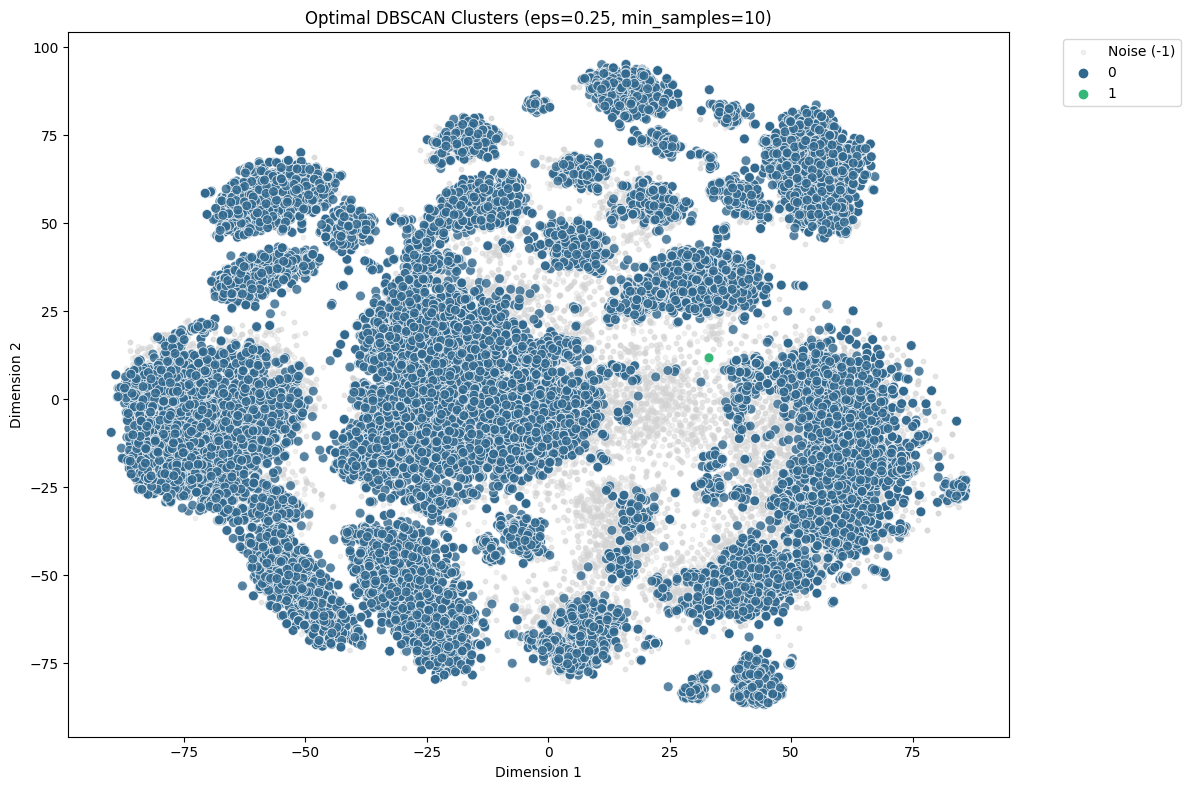

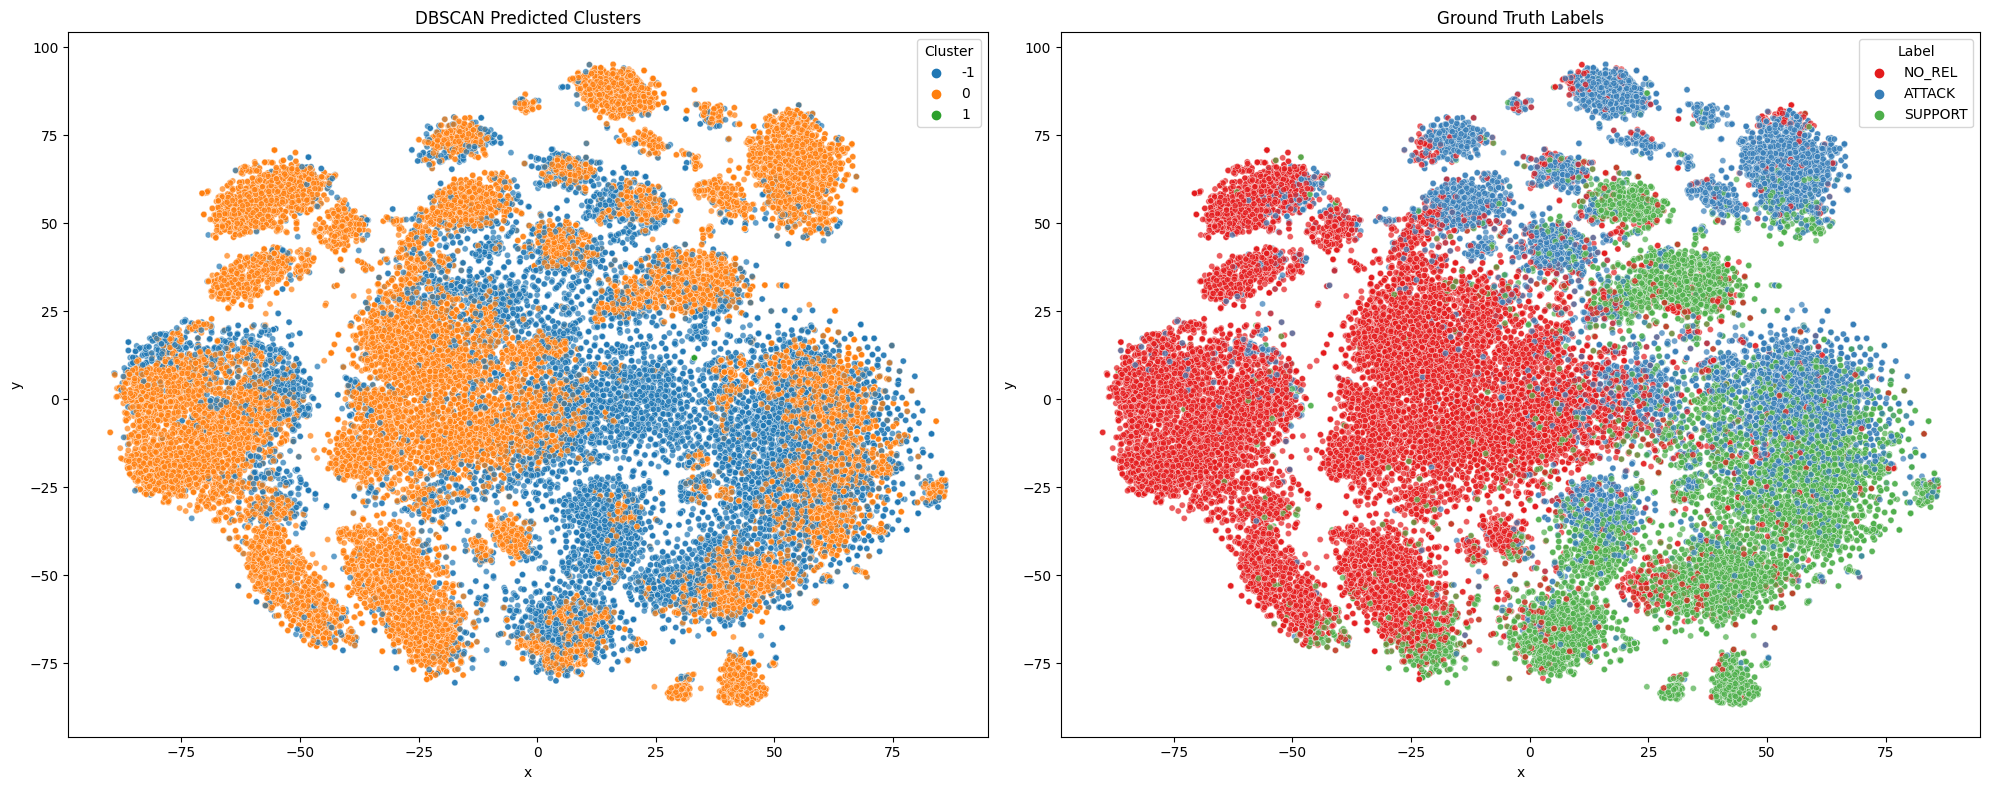

In [5]:
# --- 5. Visualize Results ---
if optimizer.best_model is not None:
    print("\n--- Generating Visualizations ---")
    
    # Initialize Visualizer with:
    # 1. Embeddings
    # 2. Labels from the best DBSCAN model
    # 3. Ground truth 'label' column from our aligned dataframe
    viz = ClusterVisualizer(
        embeddings=embeddings, 
        labels=optimizer.get_best_labels(),
        ground_truth=df_text['label']
    )

    # 1. Generate t-SNE coordinates (Computationally intensive)
    viz.reduce_dimensions(method='tsne')

    # 2. Plot the DBSCAN clusters
    viz.plot_clusters(title=f"Optimal DBSCAN Clusters (eps={optimizer.best_params['eps']}, min_samples={optimizer.best_params['min_samples']})")

    # 3. Compare with Ground Truth (Side-by-Side)
    viz.plot_vs_ground_truth()